# 04 — Pipeline: Direct Gene-Space Flow Matching

**Pipeline:** Gene Expression (2000d, standardized) → Flow Matching → inverse StandardScaler → Gene Expression

This is the simplest pipeline: flow matching operates directly on the full 2000-dimensional
standardized gene expression space, without any dimensionality reduction.

The network needs to be wider/deeper to handle the higher dimensionality,
and training takes longer, but no information is lost through compression.

In [1]:
import sys, os
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

import numpy as np
import matplotlib.pyplot as plt
import torch

import config as cfg
from src.preprocess import set_seed, load_processed
from src.models_flow import train_flow_matching
from src.metrics import distribution_metrics, plot_umap_overlay, plot_training_curves

set_seed()
print(f"Device: {cfg.DEVICE}")

Device: cuda


## 1. Load Preprocessed Data

In [2]:
data = load_processed()
X_all = data["X_all"]
X_train_s = data["X_train_s"]
X_all_s = data["X_all_s"]
scaler = data["scaler"]
hvg_names = data["hvg_names"]

print(f"Train: {X_train_s.shape}")
print(f"Input dimension for flow matching: {X_train_s.shape[1]}")

Train: (2110, 2000)
Input dimension for flow matching: 2000


## 2. Train Flow Matching in Gene Space

Using a wider network (1024 hidden) and more layers (6) to handle 2000 dimensions.
Training for 800 epochs.

Training flow matching in 2000-dim gene space...
Network: hidden=1024, layers=6, epochs=800
  Epoch [   1/800] loss=1.9950
  Epoch [ 100/800] loss=1.9110
  Epoch [ 200/800] loss=1.7713
  Epoch [ 300/800] loss=1.6483
  Epoch [ 400/800] loss=1.5698
  Epoch [ 500/800] loss=1.5468
  Epoch [ 600/800] loss=1.5134
  Epoch [ 700/800] loss=1.4988
  Epoch [ 800/800] loss=1.4796


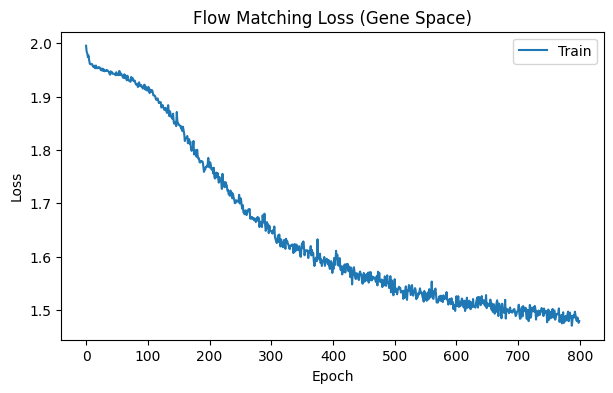

In [3]:
dim_gene = X_train_s.shape[1]
print(f"Training flow matching in {dim_gene}-dim gene space...")
print(f"Network: hidden={cfg.FM_GENE_HIDDEN}, layers={cfg.FM_GENE_LAYERS}, epochs={cfg.FM_GENE_EPOCHS}")

set_seed()
flow_gene, loss_gene = train_flow_matching(
    Z_train=X_train_s,
    dim=dim_gene,
    device=cfg.DEVICE,
    hidden=cfg.FM_GENE_HIDDEN,
    n_layers=cfg.FM_GENE_LAYERS,
    lr=cfg.FM_GENE_LR,
    batch_size=cfg.FM_GENE_BATCH_SIZE,
    n_epochs=cfg.FM_GENE_EPOCHS,
    print_every=100,
)

plot_training_curves(loss_gene, title="Flow Matching Loss (Gene Space)")
plt.show()

## 3. Generate Synthetic Cells

Sample from noise → integrate through learned flow → inverse StandardScaler

In [4]:
n_gen = len(X_all)
print(f"Generating {n_gen} synthetic cells...")

set_seed()
X_gen_gene_s = flow_gene.sample(n_gen, dim_gene, cfg.DEVICE, n_steps=cfg.FM_SAMPLE_STEPS)

# Map back: inverse StandardScaler
X_gen_gene = scaler.inverse_transform(X_gen_gene_s).astype(np.float32)

print(f"Generated shape: {X_gen_gene.shape}")
print(f"Value range: [{X_gen_gene.min():.2f}, {X_gen_gene.max():.2f}]")

Generating 2638 synthetic cells...
Generated shape: (2638, 2000)
Value range: [-6.94, 11.49]


## 4. Quick Evaluation

Gene Mean MSE: 0.000514
Gene Std MSE:  0.003710


/home/zhuoyuan/miniconda3/envs/GenAI_single_cell/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


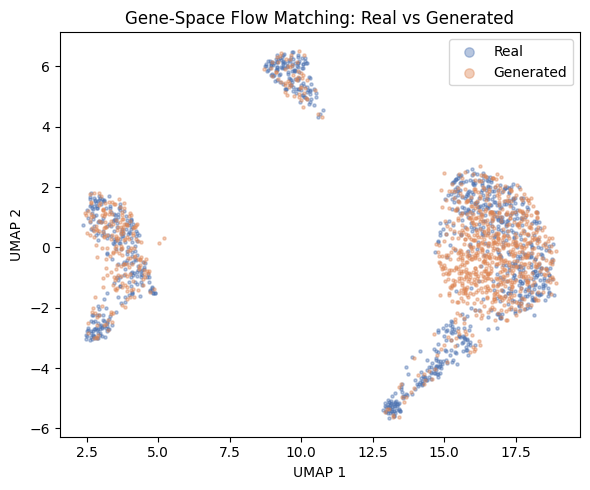

In [5]:
metrics = distribution_metrics(X_all, X_gen_gene)
print(f"Gene Mean MSE: {metrics['Mean MSE']:.6f}")
print(f"Gene Std MSE:  {metrics['Std MSE']:.6f}")

plot_umap_overlay(X_all, X_gen_gene, title="Gene-Space Flow Matching: Real vs Generated")
plt.tight_layout()
plt.show()

## 5. Save Results

In [6]:
os.makedirs(cfg.MODEL_DIR, exist_ok=True)
torch.save(flow_gene.state_dict(), os.path.join(cfg.MODEL_DIR, "flow_gene.pt"))
np.save(os.path.join(cfg.DATA_DIR, "X_gen_gene.npy"), X_gen_gene)

print("Saved: flow_gene.pt, X_gen_gene.npy")

Saved: flow_gene.pt, X_gen_gene.npy
